In [1]:
import sys
sys.path.append('../')
from utils_models import *

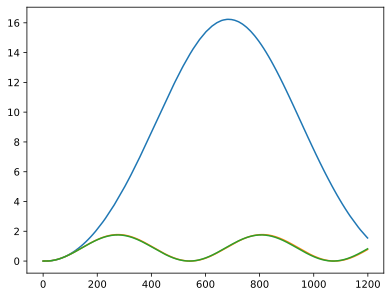

In [3]:
with open('../pickles/EJ3_leak.pkl', 'rb') as file:
    results_leak = pickle.load(file)

for result in results_leak:
    plt.plot(result.expect[1])

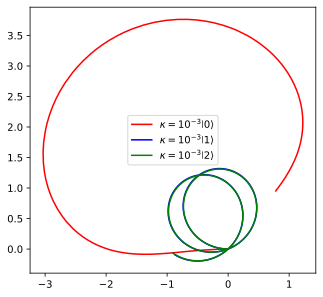

In [4]:

tlist = results_leak[0].times

prefix = rf'$\kappa = 10^{{-3}}$'
first_dominant_freq =find_dominant_frequency(results_leak[1].expect[0],tlist)

colors = ['red','blue','green']
for i, result in enumerate([results_leak[0],results_leak[1],results_leak[2]]):
    alpha = result.expect[0]*np.exp(-1j * 2 * np.pi * first_dominant_freq * tlist)
    # alpha = alpha[:550]
    plt.plot(alpha.imag,alpha.real,color=colors[i],label = prefix + rf'$\left|{i}\right>$')
plt.legend()
plt.gca().set_aspect('equal', 'box')

In [2]:
max_ql = 30
max_ol = 70
EJ = 3
EC = EJ/4
EL = EJ/19.8
Er = 8.65765533

g = 0.25
w_d = 8.660386757836488
amp = 0.0025

tot_time =1200

system =  FluxoniumOscillatorSystem(
                EJ = EJ,
                EC = EC,
                EL = EL,
                Er = Er,
                g_strength = g,
                qubit_level = max_ql,
                osc_level = max_ol,
                products_to_keep=[[ql, ol] for ql in [0,1,2] for ol in range(max_ol) ],
                computaional_states = '1,2',
                )



# dressed_indices_to_keep = []
# for qlol in system.products_to_keep:
#     dressed_indices_to_keep.append( system.product_to_dressed[(qlol[0],qlol[1])] )
# dressed_indices_to_keep = np.array(dressed_indices_to_keep)




products_to_keep = system.products_to_keep
product_to_dressed = system.product_to_dressed
qbt_position = 0
sign_multiplier = system.sign_multiplier

def get_product(dressed_dm):
    dressed_dm_data = dressed_dm#pad_back_custom(dressed_dm, products_to_keep, product_to_dressed)
    if dressed_dm_data.shape[1] == 1:
        dressed_dm_data = qutip.ket2dm(dressed_dm_data)
    dressed_dm_data = dressed_dm_data.full()

    # Infer subsystem dimensions
    subsystem_dims = [max(indexes) + 1 for indexes in zip(*product_to_dressed.keys())]
    rho_product = np.zeros((subsystem_dims*2), dtype=complex) # Here rho_product is shaped like (dim1,dim2,dim1,dim2)
    for product_state, dressed_index1 in product_to_dressed.items():
        for product_state2, dressed_index2 in product_to_dressed.items():
            element = dressed_dm_data[dressed_index1, dressed_index2] * sign_multiplier[dressed_index1] * sign_multiplier[dressed_index2]
            rho_product[product_state+product_state2] += element # Using index like (lvl1, lvl2, lvl1, lvl2) to access of of the entries

    two_lvl_qbt_dm_size = np.prod(subsystem_dims)
    rho_product = rho_product.reshape((two_lvl_qbt_dm_size,two_lvl_qbt_dm_size))
    rho_product = qutip.Qobj(rho_product, dims=[subsystem_dims, subsystem_dims])
    return rho_product


In [6]:
def plot_qfunc(results,ts):
    num_times = len(ts)
    fig, axes = plt.subplots(1,num_times,figsize = (3*num_times,3))
    lim = 10
    xvec = np.linspace(-1*lim, lim, 500)
    X, Y = np.meshgrid(xvec, xvec)

    for i, ax in enumerate(axes):

        for ql in [0,1,2]:
            dressed_dm = results[ql].states_pad_back_custom[i * 100]
            rho_product = get_product(dressed_dm)
            rho = qutip.Qobj(np.array(rho_product.ptrace(1)))
            rho = rho/rho.tr()
            Q_coherent = qutip.qfunc(rho_product.ptrace(1), xvec, xvec)
            Q_coherent[Q_coherent < 0] = 0


            q_values = Q_coherent
            sorted_q = np.sort(q_values.ravel())
            cumulative_sum = np.cumsum(sorted_q)
            total_sum = cumulative_sum[-1]
            
            for prob in [0.99,0.9,0.7,0.5,0.3,0.1]:
                level_value = sorted_q[np.argmax(cumulative_sum >= total_sum * (1 - prob))]
                contour = ax.contour(X, Y, q_values, levels=[level_value], colors=[(prob, 0, 0, 1)])
                fmt = {level_value:f'{1 - prob:.2f}'}
                ax.clabel(contour, inline=False, fontsize=8, fmt=fmt,colors='black')




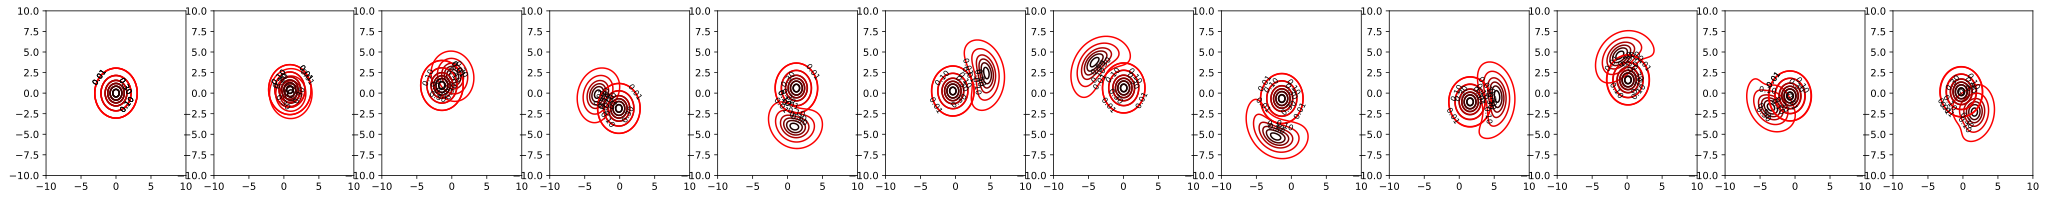

In [7]:
plot_qfunc(results_leak,[100,200,300,400,500,600,700,800,900,1000,1100,1199])

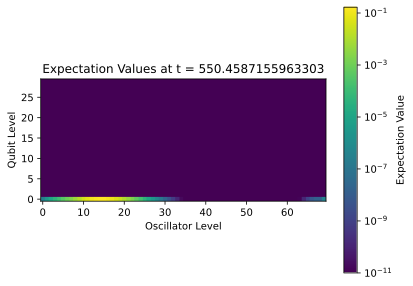

In [5]:
plot_heatmap(results_leak[0],550,system.product_to_dressed,max_ql,max_ol,LogNorm())